# 숙제 3

데이터과학 입문

손정우 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

## Setup

## R

``` r
library(tidyverse)
library(NHANES)
library(MASS)
library(broom)
library(Lahman)
```

## Python

``` python
import numpy as np
import pandas as pd
import polars as pl
from plotnine import *
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import NegativeBinomial
from scipy import stats
from scipy.special import expit
from patsy.contrasts import Treatment
from scipy.optimize import least_squares, brentq, minimize_scalar
from scipy.stats import t, norm, chi2
import warnings
from IPython.display import display
```

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

#### 1. MDSR 10장 연습문제 10.6.6.

## R

``` r
# Construct response variable
nhanes_adult <- NHANES %>%
  filter(Age >= 20) %>%
  mutate(
    current_smoker = case_when(
      Smoke100 == "No" ~ 0L,
      Smoke100 == "Yes" & SmokeNow == "Yes" ~ 1L,
      Smoke100 == "Yes" & SmokeNow == "No" ~ 0L,
      TRUE ~ NA_integer_
    )
  )

# Define variables to exclude from the candidate predictor set
leakage_vars <- c(
  "Smoke100", "SmokeNow", "Smoke100n", "SmokeAge"
)
id_vars <- c(
  "ID", "SurveyYr"
)
redundant_vars <- c(
  "AgeDecade", "AgeMonths",
  "HHIncome",
  "BMI_WHO", "BMICatUnder20yrs",
  "Weight", "Height",
  "BPSys1", "BPDia1",
  "BPSys2", "BPDia2",
  "BPSys3", "BPDia3"
)
subpopulation_vars <- c(
  "Length", "HeadCirc",
  "PregnantNow",
  "nPregnancies", "nBabies", "Age1stBaby",
  "DiabetesAge",
  "PhysActiveDays",
  "AlcoholDay", "AlcoholYear",
  "AgeFirstMarij", "AgeRegMarij",
  "SexAge", "SexNumPartnLife", "SexNumPartYear"
)
excluded_vars <- unique(c(
  "current_smoker",
  leakage_vars,
  id_vars,
  redundant_vars,
  subpopulation_vars
))
candidate_pool <- setdiff(names(nhanes_adult), excluded_vars)

# Remove variables with too much missingness
max_missing <- 0.30
missing_table <- nhanes_adult %>%
  dplyr::select(all_of(candidate_pool)) %>%
  summarize(across(everything(), ~ mean(is.na(.x)))) %>%
  pivot_longer(
    cols = everything(),
    names_to = "variable",
    values_to = "missing_rate"
  ) %>%
  arrange(missing_rate)

candidate_predictors <- missing_table %>%
  filter(missing_rate <= max_missing) %>%
  pull(variable)

# complete-case modeling data
smoke_dat <- nhanes_adult %>%
  dplyr::select(current_smoker, all_of(candidate_predictors)) %>%
  drop_na() %>%
  mutate(
    across(
      where(~ is.character(.x) || is.factor(.x)),
      ~ forcats::fct_drop(as.factor(.x))
    )
  )

# Drop predictors that have only one observed value after filtering.
candidate_predictors <- candidate_predictors[
  sapply(smoke_dat[candidate_predictors], function(x) n_distinct(x) > 1)
]

# Fit null model and run stepAIC from the null model
null_mod <- glm(
  current_smoker ~ 1,
  data = smoke_dat,
  family = binomial
)
upper_scope <- as.formula(
  paste("~", paste(candidate_predictors, collapse = " + "))
)

selected_mod <- MASS::stepAIC(
  null_mod,
  scope = list(
    lower = ~ 1,
    upper = upper_scope
  ),
  direction = "both",
  trace = FALSE
)
selected_mod$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    current_smoker ~ 1

    Final Model:
    current_smoker ~ Education + HardDrugs + MaritalStatus + Alcohol12PlusYr + 
        Race1 + PhysActive + BMI + HealthGen + HomeOwn + DirectChol + 
        SleepHrsNight + Pulse + Diabetes + BPDiaAve + Work + DaysPhysHlthBad + 
        BPSysAve + Poverty + SameSex + Depressed + TotChol + HomeRooms

                    Step Df   Deviance Resid. Df Resid. Dev      AIC
    1                                       4554   4751.314 4753.314
    2        + Education  4 370.353405      4550   4380.961 4390.961
    3        + HardDrugs  1 176.431017      4549   4204.530 4216.530
    4    + MaritalStatus  5 136.537397      4544   4067.992 4089.992
    5  + Alcohol12PlusYr  1  76.139287      4543   3991.853 4015.853
    6            + Race1  4  65.767408      4539   3926.086 3958.086
    7       + PhysActive  1  55.247598      4538   3870.838 3904.838
    8              + BMI  1  50.300874      4537   3820.537 3856.537
    9        + HealthGen  4  58.068748      4533   3762.468 3806.468
    10         + HomeOwn  2  40.099771      4531   3722.369 3770.369
    11      + DirectChol  1  20.566587      4530   3701.802 3751.802
    12   + SleepHrsNight  1  18.152550      4529   3683.650 3735.650
    13           + Pulse  1  15.586439      4528   3668.063 3722.063
    14        + Diabetes  1  13.155951      4527   3654.907 3710.907
    15        + BPDiaAve  1  10.510617      4526   3644.397 3702.397
    16            + Work  2  12.028006      4524   3632.369 3694.369
    17 + DaysPhysHlthBad  1   7.479962      4523   3624.889 3688.889
    18        + BPSysAve  1   5.757276      4522   3619.131 3685.131
    19         + Poverty  1   5.377756      4521   3613.754 3681.754
    20         + SameSex  1   4.270343      4520   3609.483 3679.483
    21       + Depressed  2   5.878905      4518   3603.604 3677.604
    22         + TotChol  1   2.696102      4517   3600.908 3676.908
    23       + HomeRooms  1   2.404932      4516   3598.503 3676.503

``` r
# likelihood-ratio tests for selected predictors
lrt_table <- drop1(selected_mod, test = "Chisq") %>%
  as.data.frame() %>%
  rownames_to_column("term") %>%
  filter(term != "<none>") %>%
  arrange(`Pr(>Chi)`)
lrt_table
```

                  term Df Deviance      AIC        LRT     Pr(>Chi)
    1        Education  4 3728.832 3798.832 130.328251 3.312856e-27
    2              BMI  1 3678.173 3754.173  79.669964 4.424764e-19
    3  Alcohol12PlusYr  1 3671.617 3747.617  73.113876 1.223811e-17
    4        HardDrugs  1 3666.238 3742.238  67.734345 1.870763e-16
    5            Race1  4 3667.460 3737.460  68.957085 3.768122e-14
    6       PhysActive  1 3646.255 3722.255  47.751350 4.838509e-12
    7    MaritalStatus  5 3656.449 3724.449  57.945691 3.227662e-11
    8        HealthGen  4 3629.482 3699.482  30.978571 3.092364e-06
    9    SleepHrsNight  1 3618.437 3694.437  19.933836 8.016888e-06
    10           Pulse  1 3617.537 3693.537  19.033817 1.284223e-05
    11      DirectChol  1 3617.199 3693.199  18.695821 1.533181e-05
    12        Diabetes  1 3616.006 3692.006  17.502960 2.868607e-05
    13         HomeOwn  2 3613.636 3687.636  15.132946 5.175145e-04
    14        BPDiaAve  1 3609.824 3685.824  11.320408 7.665988e-04
    15 DaysPhysHlthBad  1 3605.881 3681.881   7.377472 6.604594e-03
    16            Work  2 3608.363 3682.363   9.859344 7.228874e-03
    17        BPSysAve  1 3604.649 3680.649   6.145289 1.317627e-02
    18         Poverty  1 3602.566 3678.566   4.062868 4.383598e-02
    19       Depressed  2 3604.546 3678.546   6.042675 4.873598e-02
    20         SameSex  1 3601.926 3677.926   3.422311 6.432091e-02
    21         TotChol  1 3601.360 3677.360   2.856912 9.098200e-02
    22       HomeRooms  1 3600.908 3676.908   2.404932 1.209534e-01

``` r
# final identified predictors
identified_predictors <- lrt_table %>%
  filter(`Pr(>Chi)` < 0.05) %>%
  dplyr::select(term, Df, Deviance, LRT, `Pr(>Chi)`)
identified_predictors
```

                  term Df Deviance        LRT     Pr(>Chi)
    1        Education  4 3728.832 130.328251 3.312856e-27
    2              BMI  1 3678.173  79.669964 4.424764e-19
    3  Alcohol12PlusYr  1 3671.617  73.113876 1.223811e-17
    4        HardDrugs  1 3666.238  67.734345 1.870763e-16
    5            Race1  4 3667.460  68.957085 3.768122e-14
    6       PhysActive  1 3646.255  47.751350 4.838509e-12
    7    MaritalStatus  5 3656.449  57.945691 3.227662e-11
    8        HealthGen  4 3629.482  30.978571 3.092364e-06
    9    SleepHrsNight  1 3618.437  19.933836 8.016888e-06
    10           Pulse  1 3617.537  19.033817 1.284223e-05
    11      DirectChol  1 3617.199  18.695821 1.533181e-05
    12        Diabetes  1 3616.006  17.502960 2.868607e-05
    13         HomeOwn  2 3613.636  15.132946 5.175145e-04
    14        BPDiaAve  1 3609.824  11.320408 7.665988e-04
    15 DaysPhysHlthBad  1 3605.881   7.377472 6.604594e-03
    16            Work  2 3608.363   9.859344 7.228874e-03
    17        BPSysAve  1 3604.649   6.145289 1.317627e-02
    18         Poverty  1 3602.566   4.062868 4.383598e-02
    19       Depressed  2 3604.546   6.042675 4.873598e-02

``` r
# write_csv(NHANES::NHANES, "NHANES.csv")
# generated csv file to use in python
```

## Python

``` python
NHANES = pl.read_csv(
    "NHANES.csv",
    null_values=["NA", ""]
)

# Construct response variable
nhanes_adult = (
    NHANES
    .filter(pl.col("Age") >= 20)
    .with_columns(
        pl.when(pl.col("Smoke100") == "No")
        .then(pl.lit(0))
        .when(
            (pl.col("Smoke100") == "Yes") &
            (pl.col("SmokeNow") == "Yes")
        )
        .then(pl.lit(1))
        .when(
            (pl.col("Smoke100") == "Yes") &
            (pl.col("SmokeNow") == "No")
        )
        .then(pl.lit(0))
        .otherwise(None)
        .cast(pl.Int64)
        .alias("current_smoker")
    )
)

# Define variables to exclude from the candidate predictor set
leakage_vars = [
    "Smoke100", "SmokeNow", "Smoke100n", "SmokeAge"
]
id_vars = [
    "ID", "SurveyYr"
]
redundant_vars = [
    "AgeDecade", "AgeMonths",
    "HHIncome",
    "BMI_WHO", "BMICatUnder20yrs",
    "Weight", "Height",
    "BPSys1", "BPDia1",
    "BPSys2", "BPDia2",
    "BPSys3", "BPDia3"
]
subpopulation_vars = [
    "Length", "HeadCirc",
    "PregnantNow",
    "nPregnancies", "nBabies", "Age1stBaby",
    "DiabetesAge",
    "PhysActiveDays",
    "AlcoholDay", "AlcoholYear",
    "AgeFirstMarij", "AgeRegMarij",
    "SexAge", "SexNumPartnLife", "SexNumPartYear"
]

excluded_vars = list(dict.fromkeys(
    ["current_smoker"]
    + leakage_vars
    + id_vars
    + redundant_vars
    + subpopulation_vars
))
candidate_pool = [
    col for col in nhanes_adult.columns
    if col not in excluded_vars
]

# Remove variables with too much missingness
max_missing = 0.30
missing_rates = (
    nhanes_adult
    .select([
        pl.col(col).is_null().mean().alias(col)
        for col in candidate_pool
    ])
    .row(0)
)
missing_table = (
    pl.DataFrame({
        "variable": candidate_pool,
        "missing_rate": list(missing_rates)
    })
    .sort("missing_rate")
)

candidate_predictors = (
    missing_table
    .filter(pl.col("missing_rate") <= max_missing)
    .get_column("variable")
    .to_list()
)

# Complete-case modeling data
smoke_dat_pl = (
    nhanes_adult
    .select(["current_smoker"] + candidate_predictors)
    .drop_nulls()
)

# Identify categorical variables.
categorical_vars = [
    col for col in candidate_predictors
    if smoke_dat_pl.schema[col] == pl.Utf8
]

# Drop predictors that have only one observed value after filtering.
n_unique_values = (
    smoke_dat_pl
    .select([
        pl.col(col).n_unique().alias(col)
        for col in candidate_predictors
    ])
    .row(0)
)
candidate_predictors = [
    col for col, n_unique in zip(candidate_predictors, n_unique_values)
    if n_unique > 1
]
categorical_vars = [
    col for col in categorical_vars
    if col in candidate_predictors
]

smoke_dat_pl = smoke_dat_pl.select(
    ["current_smoker"] + candidate_predictors
)

# Convert to pandas for statsmodels
smoke_dat = smoke_dat_pl.to_pandas()

# Match R's unordered factor behavior
for col in categorical_vars:
    levels = sorted(smoke_dat[col].dropna().unique())

    smoke_dat[col] = pd.Categorical(
        smoke_dat[col],
        categories=levels,
        ordered=False
    )

# Helper functions for GLM formulas and model fitting
def q(var):
    """
    Quote variable names safely for Patsy formulas.
    """
    return f'Q("{var}")'


def formula_term(var):
    """
    Match R glm behavior:
    - Numeric variables enter linearly.
    - Unordered categorical variables use treatment coding.
    """
    if var in categorical_vars:
        return f'C({q(var)}, Treatment(reference=0))'
    return q(var)


def make_formula(response, terms):
    if len(terms) == 0:
        return f'{q(response)} ~ 1'

    rhs = " + ".join(formula_term(term) for term in terms)
    return f'{q(response)} ~ {rhs}'


def fit_glm_binomial(terms):
    """
    Fit logistic regression with IRLS.

    R's glm() default is approximately:
    glm.control(epsilon = 1e-8, maxit = 25)
    """
    formula = make_formula("current_smoker", terms)

    model = smf.glm(
        formula=formula,
        data=smoke_dat,
        family=sm.families.Binomial()
    ).fit(
        method="IRLS",
        maxiter=25,
        tol=1e-8
    )

    return model

# Fit null model and run stepAIC from the null model
def stepwise_aic_from_null(candidate_terms, trace=False, tol=1e-8):
    """
    Python analogue of:

    MASS::stepAIC(
      null_mod,
      scope = list(lower = ~ 1, upper = upper_scope),
      direction = "both",
      trace = FALSE
    )

    At each step, this function tries adding or dropping one term.
    It moves to the model with the lowest AIC if that AIC improves.
    """

    current_terms = []
    current_model = fit_glm_binomial(current_terms)
    current_aic = current_model.aic

    path = [{
        "Action": "Start",
        "Term": "<none>",
        "Df_Model": current_model.df_model,
        "Resid_Df": current_model.df_resid,
        "Deviance": current_model.deviance,
        "AIC": current_model.aic
    }]

    step = 1

    while True:
        candidate_moves = []

        # Try dropping each term currently in the model
        for term in current_terms:
            trial_terms = [
                t for t in current_terms
                if t != term
            ]

            try:
                trial_model = fit_glm_binomial(trial_terms)

                candidate_moves.append({
                    "action": "Drop",
                    "term": term,
                    "terms": trial_terms,
                    "model": trial_model,
                    "AIC": trial_model.aic
                })
            except Exception:
                pass

        # Try adding each term not currently in the model
        for term in candidate_terms:
            if term not in current_terms:
                trial_terms = current_terms + [term]

                try:
                    trial_model = fit_glm_binomial(trial_terms)

                    candidate_moves.append({
                        "action": "Add",
                        "term": term,
                        "terms": trial_terms,
                        "model": trial_model,
                        "AIC": trial_model.aic
                    })
                except Exception:
                    pass

        if len(candidate_moves) == 0:
            break

        best_move = min(candidate_moves, key=lambda x: x["AIC"])

        if best_move["AIC"] + tol < current_aic:
            current_terms = best_move["terms"]
            current_model = best_move["model"]
            current_aic = best_move["AIC"]

            path.append({
                "Action": best_move["action"],
                "Term": best_move["term"],
                "Df_Model": current_model.df_model,
                "Resid_Df": current_model.df_resid,
                "Deviance": current_model.deviance,
                "AIC": current_model.aic
            })

            if trace:
                print(
                    f"Step {step}: {best_move['action']} {best_move['term']}, "
                    f"AIC = {current_aic:.4f}"
                )

            step += 1
        else:
            break

    return current_model, current_terms, pd.DataFrame(path)


selected_mod, selected_terms, step_path = stepwise_aic_from_null(
    candidate_terms=candidate_predictors,
    trace=False,
    tol=1e-8
)

print(step_path) # Stepwise AIC selection path 
```

       Action             Term  Df_Model  Resid_Df     Deviance          AIC
    0   Start           <none>         0      4554  4751.314196  4753.314196
    1     Add        Education         4      4550  4380.960792  4390.960792
    2     Add        HardDrugs         5      4549  4204.529775  4216.529775
    3     Add    MaritalStatus        10      4544  4067.992378  4089.992378
    4     Add  Alcohol12PlusYr        11      4543  3991.853091  4015.853091
    5     Add            Race1        15      4539  3926.085683  3958.085683
    6     Add       PhysActive        16      4538  3870.838086  3904.838086
    7     Add              BMI        17      4537  3820.537212  3856.537212
    8     Add        HealthGen        21      4533  3762.468464  3806.468464
    9     Add          HomeOwn        23      4531  3722.368693  3770.368693
    10    Add       DirectChol        24      4530  3701.802106  3751.802106
    11    Add    SleepHrsNight        25      4529  3683.649556  3735.649556
    12    Add            Pulse        26      4528  3668.063117  3722.063117
    13    Add         Diabetes        27      4527  3654.907166  3710.907166
    14    Add         BPDiaAve        28      4526  3644.396549  3702.396549
    15    Add             Work        30      4524  3632.368543  3694.368543
    16    Add  DaysPhysHlthBad        31      4523  3624.888581  3688.888581
    17    Add         BPSysAve        32      4522  3619.131305  3685.131305
    18    Add          Poverty        33      4521  3613.753549  3681.753549
    19    Add          SameSex        34      4520  3609.483206  3679.483206
    20    Add        Depressed        36      4518  3603.604301  3677.604301
    21    Add          TotChol        37      4517  3600.908199  3676.908199
    22    Add        HomeRooms        38      4516  3598.503267  3676.503267

``` python
# Likelihood-ratio tests for selected predictors
def drop1_lrt(full_model, selected_terms):
    """
    Python equivalent of:

    drop1(selected_mod, test = "Chisq")

    For each selected term, compare:

    full model:
        selected model

    reduced model:
        selected model with that term removed

    Columns:
    - Df: number of parameters removed
    - Deviance: residual deviance of the reduced model
    - AIC: AIC of the reduced model
    - LRT: likelihood-ratio statistic
    - Pr(>Chi): chi-square p-value
    """

    rows = []

    full_deviance = full_model.deviance
    full_df_model = full_model.df_model

    for term in selected_terms:
        reduced_terms = [
            t for t in selected_terms
            if t != term
        ]

        reduced_model = fit_glm_binomial(reduced_terms)

        df_diff = int(round(full_df_model - reduced_model.df_model))
        lrt_stat = reduced_model.deviance - full_deviance
        p_value = stats.chi2.sf(lrt_stat, df_diff)

        rows.append({
            "term": term,
            "Df": df_diff,
            "Deviance": reduced_model.deviance,
            "AIC": reduced_model.aic,
            "LRT": lrt_stat,
            "Pr(>Chi)": p_value
        })

    return (
        pd.DataFrame(rows)
        .sort_values("Pr(>Chi)")
        .reset_index(drop=True)
    )

lrt_table = drop1_lrt(selected_mod, selected_terms)
print(lrt_table)
```

                   term  Df     Deviance          AIC         LRT      Pr(>Chi)
    0         Education   4  3728.831518  3798.831518  130.328251  3.312856e-27
    1               BMI   1  3678.173231  3754.173231   79.669964  4.424764e-19
    2   Alcohol12PlusYr   1  3671.617144  3747.617144   73.113876  1.223811e-17
    3         HardDrugs   1  3666.237612  3742.237612   67.734345  1.870763e-16
    4             Race1   4  3667.460353  3737.460353   68.957085  3.768122e-14
    5        PhysActive   1  3646.254617  3722.254617   47.751350  4.838509e-12
    6     MaritalStatus   5  3656.448959  3724.448959   57.945691  3.227662e-11
    7         HealthGen   4  3629.481838  3699.481838   30.978571  3.092364e-06
    8     SleepHrsNight   1  3618.437103  3694.437103   19.933836  8.016888e-06
    9             Pulse   1  3617.537084  3693.537084   19.033817  1.284223e-05
    10       DirectChol   1  3617.199088  3693.199088   18.695821  1.533181e-05
    11         Diabetes   1  3616.006228  3692.006228   17.502960  2.868607e-05
    12          HomeOwn   2  3613.636213  3687.636213   15.132946  5.175145e-04
    13         BPDiaAve   1  3609.823675  3685.823675   11.320408  7.665988e-04
    14  DaysPhysHlthBad   1  3605.880740  3681.880740    7.377472  6.604594e-03
    15             Work   2  3608.362611  3682.362611    9.859344  7.228874e-03
    16         BPSysAve   1  3604.648556  3680.648556    6.145289  1.317627e-02
    17          Poverty   1  3602.566136  3678.566136    4.062868  4.383598e-02
    18        Depressed   2  3604.545943  3678.545943    6.042675  4.873598e-02
    19          SameSex   1  3601.925578  3677.925578    3.422311  6.432091e-02
    20          TotChol   1  3601.360180  3677.360180    2.856912  9.098200e-02
    21        HomeRooms   1  3600.908199  3676.908199    2.404932  1.209534e-01

``` python
# Final identified predictors
identified_predictors = (
    lrt_table
    .loc[
        lrt_table["Pr(>Chi)"] < 0.05,
        ["term", "Df", "Deviance", "LRT", "Pr(>Chi)"]
    ]
    .reset_index(drop=True)
)
print(identified_predictors)
```

                   term  Df     Deviance         LRT      Pr(>Chi)
    0         Education   4  3728.831518  130.328251  3.312856e-27
    1               BMI   1  3678.173231   79.669964  4.424764e-19
    2   Alcohol12PlusYr   1  3671.617144   73.113876  1.223811e-17
    3         HardDrugs   1  3666.237612   67.734345  1.870763e-16
    4             Race1   4  3667.460353   68.957085  3.768122e-14
    5        PhysActive   1  3646.254617   47.751350  4.838509e-12
    6     MaritalStatus   5  3656.448959   57.945691  3.227662e-11
    7         HealthGen   4  3629.481838   30.978571  3.092364e-06
    8     SleepHrsNight   1  3618.437103   19.933836  8.016888e-06
    9             Pulse   1  3617.537084   19.033817  1.284223e-05
    10       DirectChol   1  3617.199088   18.695821  1.533181e-05
    11         Diabetes   1  3616.006228   17.502960  2.868607e-05
    12          HomeOwn   2  3613.636213   15.132946  5.175145e-04
    13         BPDiaAve   1  3609.823675   11.320408  7.665988e-04
    14  DaysPhysHlthBad   1  3605.880740    7.377472  6.604594e-03
    15             Work   2  3608.362611    9.859344  7.228874e-03
    16         BPSysAve   1  3604.648556    6.145289  1.317627e-02
    17          Poverty   1  3602.566136    4.062868  4.383598e-02
    18        Depressed   2  3604.545943    6.042675  4.873598e-02

문제에서 단순히 하나의 logistic regression model을 fitting하라고 한 것이
아니라 “identify predictors”라고 했으므로 변수선택을 stepAIC()를
활용하여 진행한다. stepAIC()를 통해 선택된 설명변수들 각각에 대해서도
likelihood-ratio test를 통해 유의한지 확인한다. stepAIC()를 call하기
전에 candidate predictors를 추린다. 흡연여부와 직접적으로 관련되어
leakage 문제가 생길 수 있는 SmokeAge 등의 변수는 설명변수로 사용하는
것이 부적절하므로 제외한다. 또한, 변수들 중 redundant(예: Age와
AgeDecade는 너무 비슷한 정보 가지고 있음)한 것이 많아 적절히 추려서
사용한다. Missing data가 너무 많은 variable도 사용할 수 있는 sample
size를 너무 줄일 수 있기에 제외한다. ID, SurveyYr 처럼 데이터 식별용으로
존재하는 것들도 제외한다. PregnantNow 처럼 모든 사람이 아닌
subpopulation에 대해서만 측정된 변수도 제외한다.

Python은 R과 달리 stepAIC() 함수가 구현되어 있지 않아 직접 구현하여
사용한다. 두 언어의 실행 결과가 consistent하도록 하기 위해 python의
구현에서 R의 coding matrix와 default hyperparameters를 최대한 맞추려고
하였다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

#### 문제 2-1-1.

## R

``` r
dim(Teams)
```

    [1] 3614   48

``` r
# observational unit에 문제 없는지 확인. 
Teams %>% 
  group_by(teamID, yearID) %>% 
  summarize(count = n()) %>% 
  pull(count) %>% 
  unique()
```

    [1] 1

``` r
teams_bj <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  mutate(
    RS = R,              # Runs scored
    WPct = W / (W + L)   # Winning percentage
  ) %>%
  filter(
    !is.na(WPct),
    !is.na(RS),
    !is.na(RA),
    RS > 0,
    RA > 0
  )

# Fit nonlinear least-squares model
bj_nls <- nls(
  WPct ~ 1 / (1 + (RA / RS)^k),
  data = teams_bj,
  start = list(k = 2),   # 원래 Bill James의 모델을 초기값으로 사용. 
  control = nls.control(
    maxiter = 100,
    warnOnly = TRUE
  )
)

# Point estimate and confidence interval for k
k_hat <- coef(bj_nls)[["k"]]

k_ci <- confint(
  bj_nls,
  parm = "k",
  level = 0.95
)

k_ci
```

        2.5%    97.5% 
    1.695234 1.810559 

``` r
k_result <- tibble(
  parameter = "k",
  estimate = k_hat,
  conf.low = k_ci[1],
  conf.high = k_ci[2],
  conf.level = 0.95,
  ci.method = "profile"
)
k_result
```

    # A tibble: 1 × 6
      parameter estimate conf.low conf.high conf.level ci.method
      <chr>        <dbl>    <dbl>     <dbl>      <dbl> <chr>    
    1 k             1.75     1.70      1.81       0.95 profile  

## Python

``` python
Teams = pl.from_pandas(r.Teams)
print(Teams.shape)
```

    (3614, 48)

``` python
teams_bj = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        pl.col("R").alias("RS"),
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct")
    )
    .filter(
        pl.col("WPct").is_not_null() &
        pl.col("RS").is_not_null() &
        pl.col("RA").is_not_null() &
        (pl.col("RS") > 0) &
        (pl.col("RA") > 0)
    )
)

# Convert columns needed for scipy to numpy arrays
RS = teams_bj.get_column("RS").to_numpy().astype(float)
RA = teams_bj.get_column("RA").to_numpy().astype(float)
WPct = teams_bj.get_column("WPct").to_numpy().astype(float)


def bill_james_pred(k, RS, RA):
    return 1 / (1 + (RA / RS) ** k)


def residuals(par):
    k = par[0]
    return WPct - bill_james_pred(k, RS, RA)


fit = least_squares(
    residuals,
    x0=np.array([2.0]), 
    max_nfev=100
)

if not fit.success:
    print("\nWarning: nonlinear least-squares optimization did not fully converge.")
    print(fit.message)

k_hat = fit.x[0]


# Profile confidence interval for k

# The profile-t confidence interval solves:
#   sqrt((RSS(k) - RSS(k_hat)) / sigma_hat^2) = t_{n-p, 0.975}

def rss_at(k):
    resid = WPct - bill_james_pred(k, RS, RA)
    return np.sum(resid ** 2)


rss_min = rss_at(k_hat)

n = len(WPct)
p = 1
df = n - p

sigma_hat_sq = rss_min / df
t_cutoff = t.ppf(0.975, df)

target_rss = rss_min + sigma_hat_sq * t_cutoff ** 2


def profile_root_function(k):
    return rss_at(k) - target_rss


def find_profile_bound(k_center, direction, initial_step=0.1, max_iter=100):
    """
    Finds one side of the profile confidence interval.

    direction = -1 for lower bound
    direction =  1 for upper bound
    """

    step = max(initial_step, abs(k_center) * 0.05)

    for _ in range(max_iter):
        candidate = k_center + direction * step

        if profile_root_function(candidate) > 0:
            if direction < 0:
                return brentq(profile_root_function, candidate, k_center)
            else:
                return brentq(profile_root_function, k_center, candidate)

        step *= 1.5

    raise RuntimeError("Could not find profile confidence interval bound.")


conf_low = find_profile_bound(k_hat, direction=-1)
conf_high = find_profile_bound(k_hat, direction=1)

k_ci = pd.Series(
    [conf_low, conf_high],
    index=["2.5%", "97.5%"],
    name="k"
)

k_result = pl.DataFrame({
    "parameter": ["k"],
    "estimate": [k_hat],
    "conf.low": [conf_low],
    "conf.high": [conf_high],
    "conf.level": [0.95],
    "ci.method": ["profile"]
})

print(k_result)
```

    shape: (1, 6)
    ┌───────────┬──────────┬──────────┬───────────┬────────────┬───────────┐
    │ parameter ┆ estimate ┆ conf.low ┆ conf.high ┆ conf.level ┆ ci.method │
    │ ---       ┆ ---      ┆ ---      ┆ ---       ┆ ---        ┆ ---       │
    │ str       ┆ f64      ┆ f64      ┆ f64       ┆ f64        ┆ str       │
    ╞═══════════╪══════════╪══════════╪═══════════╪════════════╪═══════════╡
    │ k         ┆ 1.752794 ┆ 1.695234 ┆ 1.810558  ┆ 0.95       ┆ profile   │
    └───────────┴──────────┴──────────┴───────────┴────────────┴───────────┘

Non-linear least squares 는 closed form formula가 없으므로 알고리즘의
초기값을 지정해주어야 하는데, Bill James의 원래 모형인 k=2를 초기값으로
사용하였다.

R의 경우 신뢰구간을 생성할 때 MASS의 confint()를 통해 프로파일링
신뢰구간을 계산하였다. Python의 경우 패키지에 구현되어 있는 프로파일링
신뢰구간 함수가 없어서 직접 구현하였다. 이 문제의 모델의 경우 모수가 k
하나여서 비교적 쉽게 가능하였다.

#### 문제 2-1-2.

$$  logit(WPct) = \beta_1 \log{\frac{RS}{RA}} \iff WPct = \frac{1}{1+(RA / RS)^{\beta1}}$$
이므로 $\log{\frac{RS}{RA}}$ 를 설명변수로 하는 절편이 없는 logistic
regression을 적합한다.

Observational unit i에 대해 W_i 번의 success와 L_i 번의 failure 를
관측한 것으로 간주하고 적합을 진행한다.

## R

``` r
# Since W is the number of wins out of W + L games, 
# we fit a grouped binomial model using cbind(W, L)

teams_bj <- teams_bj %>%
  mutate(
    eta = log(RS / RA)
  )

bj_glm <- glm(
  cbind(W, L) ~ 0 + eta,
  data = teams_bj,
  family = binomial
)

beta1_hat <- coef(bj_glm)[["eta"]]

beta1_ci <- confint(
  bj_glm,
  parm = "eta",
  level = 0.95
)

glm_result <- tibble(
  parameter = "beta_1",
  estimate = beta1_hat,
  conf.low = beta1_ci[1],
  conf.high = beta1_ci[2],
  conf.level = 0.95,
)
glm_result
```

    # A tibble: 1 × 5
      parameter estimate conf.low conf.high conf.level
      <chr>        <dbl>    <dbl>     <dbl>      <dbl>
    1 beta_1        1.75     1.66      1.84       0.95

## Python

``` python
teams_bj = teams_bj.with_columns(
    (pl.col("RS") / pl.col("RA")).log().alias("eta")
)

teams_bj_pd = teams_bj.to_pandas()

# two-column matrix of successes and failures
y = teams_bj_pd[["W", "L"]].to_numpy()

# Explanatory variable eta, no intercept
X = teams_bj_pd[["eta"]].to_numpy()

bj_glm = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
).fit()

beta1_hat = bj_glm.params[0]

# Profile-likelihood confidence interval for beta_1
W = teams_bj_pd["W"].to_numpy(dtype=float)
L = teams_bj_pd["L"].to_numpy(dtype=float)
eta = teams_bj_pd["eta"].to_numpy(dtype=float)

def loglik(beta):
    """
    Binomial log-likelihood up to constants.

    p_i = sigmoid(beta * eta_i)
    W_i ~ Binomial(W_i + L_i, p_i)

    Constants do not matter for likelihood-ratio confidence intervals.
    """
    linear_pred = beta * eta

    # Stable computation of:
    # W * log(p) + L * log(1 - p)
    #
    # where p = sigmoid(linear_pred)
    return np.sum(W * linear_pred - (W + L) * np.logaddexp(0, linear_pred))


ll_hat = loglik(beta1_hat)
z_cutoff = norm.ppf(0.975)
target = z_cutoff ** 2

def profile_eq(beta):
    return 2 * (ll_hat - loglik(beta)) - target


def find_profile_bound(beta_hat, direction, initial_step=0.1, max_iter=100):
    """
    Find lower or upper profile-likelihood CI bound.

    direction = -1 for lower bound
    direction =  1 for upper bound
    """
    step = initial_step

    for _ in range(max_iter):
        candidate = beta_hat + direction * step

        if profile_eq(candidate) > 0:
            if direction < 0:
                return brentq(profile_eq, candidate, beta_hat)
            else:
                return brentq(profile_eq, beta_hat, candidate)

        step *= 1.5

    raise RuntimeError("Could not find profile confidence interval bound.")


beta1_ci_low = find_profile_bound(beta1_hat, direction=-1)
beta1_ci_high = find_profile_bound(beta1_hat, direction=1)

beta1_ci = pd.Series(
    [beta1_ci_low, beta1_ci_high],
    index=["2.5%", "97.5%"],
    name="eta"
)

glm_result = pd.DataFrame({
    "parameter": ["beta_1"],
    "estimate": [beta1_hat],
    "conf.low": [beta1_ci_low],
    "conf.high": [beta1_ci_high],
    "conf.level": [0.95]
})

print(glm_result)
```

      parameter  estimate  conf.low  conf.high  conf.level
    0    beta_1  1.753203  1.663879   1.842698        0.95

Point estimate 은 1번의 비선형 모델과 거의 일치한다. 신뢰구간은 비선형
모델보다 약간 더 넓게 나오는데 큰 차이는 없어 보인다.

신뢰구간을 구할 때 python의 경우 1항과 마찬가지로 직접 함수를 구현하여
계산한다.

#### 문제 2-1-3.

## R

``` r
# Add fitted values and residuals for diagnostics
teams_bj_aug <- teams_bj %>%
  mutate(
    fitted_link = predict(bj_glm, type = "link"),
    fitted_WPct = predict(bj_glm, type = "response"),
    deviance_resid = residuals(bj_glm, type = "deviance")
  )

# i: Residual deviance compared with chi-square distribution
resid_dev <- deviance(bj_glm)
resid_df <- df.residual(bj_glm)

deviance_diagnostic <- tibble(
  residual_deviance = resid_dev,
  df = resid_df,
  deviance_over_df = resid_dev / resid_df,
)
deviance_diagnostic
```

    # A tibble: 1 × 3
      residual_deviance    df deviance_over_df
                  <dbl> <int>            <dbl>
    1              180.   449            0.401

``` r
# ii: Deviance residuals vs linear predictors eta
ggplot(teams_bj_aug, aes(x = fitted_link, y = deviance_resid)) +
  geom_point(alpha = 0.6) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    title = "Deviance Residuals vs Linear Predictors",
    x = expression(hat(beta)[1] * log(RS / RA)),
    y = "Deviance residual"
  ) +
  theme_minimal()
```

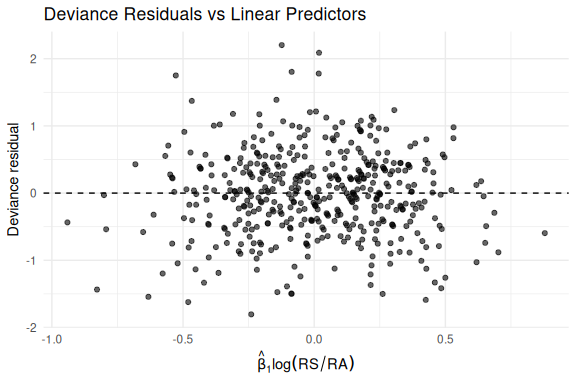

``` r
# iii: Observed WPct vs predicted WPct
ggplot(teams_bj_aug, aes(x = fitted_WPct, y = WPct)) +
  geom_point(alpha = 0.6) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  labs(
    title = "Observed vs Predicted Winning Percentage",
    x = "Predicted WPct",
    y = "Observed WPct"
  ) +
  coord_equal() +
  theme_minimal()
```

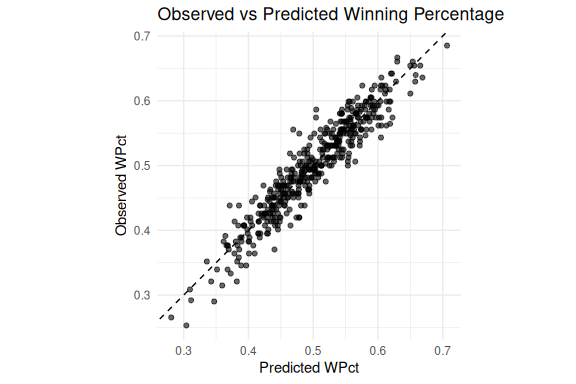

## Python

``` python
# Add fitted values and residuals for diagnostics

# Convert to pandas for statsmodels outputs and plotnine
teams_bj_pd = teams_bj.to_pandas().copy()

beta1_hat = bj_glm.params[0]

teams_bj_pd["fitted_link"] = beta1_hat * teams_bj_pd["eta"]
teams_bj_pd["fitted_WPct"] = expit(teams_bj_pd["fitted_link"])
teams_bj_pd["deviance_resid"] = bj_glm.resid_deviance

teams_bj_aug = pl.from_pandas(teams_bj_pd)

# i: Residual deviance compared with chi-square distribution

resid_dev = bj_glm.deviance
resid_df = bj_glm.df_resid

deviance_diagnostic = pd.DataFrame({
    "residual_deviance": [resid_dev],
    "df": [resid_df],
    "deviance_over_df": [resid_dev / resid_df]
})
print(deviance_diagnostic)
```

       residual_deviance   df  deviance_over_df
    0         180.263179  449          0.401477

``` python
# ii: Deviance residuals vs linear predictors eta
p1 = (
    ggplot(teams_bj_pd, aes(x="fitted_link", y="deviance_resid"))
    + geom_point(alpha=0.6)
    + geom_hline(yintercept=0, linetype="dashed")
    + labs(
        title="Deviance Residuals vs Linear Predictors",
        x="beta_hat_1 * log(RS / RA)",
        y="Deviance residual"
    )
    + theme_minimal()
)
display(p1)
```

    <ggplot: (640 x 480)>

``` python
# iii: Observed WPct vs predicted WPct
p2 = (
    ggplot(teams_bj_pd, aes(x="fitted_WPct", y="WPct"))
    + geom_point(alpha=0.6)
    + geom_abline(
        intercept=0,
        slope=1,
        linetype="dashed"
    )
    + labs(
        title="Observed vs Predicted Winning Percentage",
        x="Predicted WPct",
        y="Observed WPct"
    )
    + coord_equal()
    + theme_minimal()
)
display(p2)
```

    <ggplot: (640 x 480)>

(i)에서 residual deviance 180.26이 asymptotic 카이제곱 자유도 449와
비교했을 때 훨씬 작은 것을 확인할 수 있다. 적합된 모델에 lack of fit
문제는 없다고 볼 수 있다.

(ii)에서 deviance residual과 linear predictor 사이에 눈에 띄는 패턴이
보이지 않는다.

(iii)에서 관측된 WPct와 예측된 WPct가 y=x 근처에 특별한 패턴 없이
흩뿌려져 있음을 확인할 수 있다.

세 가지 결과를 종합해봤을 때 적합된 모형이 적절하다고 결론 내릴 수 있다.

#### 문제 2-1-4.

## R

``` r
teams_bj <- teams_bj %>%
  mutate(
    log_RA = log(RA),
    log_RS = log(RS)
  )

bj_glm_log <- glm(
  cbind(W, L) ~ 0 + log_RS + log_RA,
  data = teams_bj,
  family = binomial
)

# Coefficient estimates and confidence intervals
coef_log <- coef(bj_glm_log)
coef_log_ci <- confint(
  bj_glm_log,
  parm = c("log_RA", "log_RS"),
  level = 0.95
)

log_model_result <- tibble(
  parameter = c("beta_RA", "beta_RS"),
  term = c("log_RA", "log_RS"),
  estimate = c(coef_log[["log_RA"]], coef_log[["log_RS"]]),
  conf.low = c(coef_log_ci["log_RA", 1], coef_log_ci["log_RS", 1]),
  conf.high = c(coef_log_ci["log_RA", 2], coef_log_ci["log_RS", 2]),
  conf.level = 0.95
)
log_model_result
```

    # A tibble: 2 × 6
      parameter term   estimate conf.low conf.high conf.level
      <chr>     <chr>     <dbl>    <dbl>     <dbl>      <dbl>
    1 beta_RA   log_RA    -1.75    -1.84     -1.66       0.95
    2 beta_RS   log_RS     1.75     1.66      1.84       0.95

``` r
# Compare with previous models
comparison_table <- tibble(
  quantity = c(
    "k from nls model",
    "beta_1 from eta-only logistic model",
    "beta_RS from log(RS), log(RA) model",
    "- beta_RA from log(RS), log(RA) model",
    "beta_RA + beta_RS"
  ),
  value = c(
    k_hat,
    beta1_hat,
    coef_log[["log_RS"]],
    -coef_log[["log_RA"]],
    coef_log[["log_RA"]] + coef_log[["log_RS"]]
  )
)
comparison_table
```

    # A tibble: 5 × 2
      quantity                                  value
      <chr>                                     <dbl>
    1 k from nls model                       1.75    
    2 beta_1 from eta-only logistic model    1.75    
    3 beta_RS from log(RS), log(RA) model    1.75    
    4 - beta_RA from log(RS), log(RA) model  1.75    
    5 beta_RA + beta_RS                     -0.000409

``` r
# Nested model comparison with ANOVA
anova(bj_glm, bj_glm_log, test="Chisq")
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ 0 + eta
    Model 2: cbind(W, L) ~ 0 + log_RS + log_RA
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)
    1       449     180.26                     
    2       448     180.13  1  0.12843   0.7201

## Python

``` python
teams_bj = teams_bj.with_columns(
    pl.col("RA").log().alias("log_RA"),
    pl.col("RS").log().alias("log_RS")
)

teams_bj_pd = teams_bj.to_pandas().copy()

y = teams_bj_pd[["W", "L"]]
X_log = teams_bj_pd[["log_RS", "log_RA"]]   # no intercept

bj_glm_log = sm.GLM(
    y,
    X_log,
    family=sm.families.Binomial()
).fit()


coef_log = bj_glm_log.params

# Profile-likelihood confidence intervals
# The confidence set for one parameter solves:
#
#   2 * {logLik(beta_hat) - profile_logLik(beta_j)} <= chi^2_{1, 0.95}
#
# For each fixed beta_j, we maximize over the other coefficient.

W = teams_bj_pd["W"].to_numpy(dtype=float)
L = teams_bj_pd["L"].to_numpy(dtype=float)
G = W + L

log_RS = teams_bj_pd["log_RS"].to_numpy(dtype=float)
log_RA = teams_bj_pd["log_RA"].to_numpy(dtype=float)

X_np = np.column_stack([log_RS, log_RA])
param_names = ["log_RS", "log_RA"]

beta_hat = coef_log[param_names].to_numpy()

def loglik(beta):
    """
    Binomial log-likelihood up to constants.

    p_i = sigmoid(beta_RS * log_RS_i + beta_RA * log_RA_i)
    W_i ~ Binomial(W_i + L_i, p_i)

    Constants are omitted because they cancel in likelihood-ratio intervals.
    """
    linear_pred = X_np @ beta
    return np.sum(W * linear_pred - G * np.logaddexp(0, linear_pred))


ll_hat = loglik(beta_hat)
lr_cutoff = chi2.ppf(0.95, df=1)

def profile_loglik(fixed_index, fixed_value):
    """
    Profile log-likelihood for one fixed coefficient.
    Since there are only two coefficients, we optimize over the other one.
    """
    other_index = 1 - fixed_index
    other_hat = beta_hat[other_index]

    def objective(other_value):
        beta = beta_hat.copy()
        beta[fixed_index] = fixed_value
        beta[other_index] = other_value
        return -loglik(beta)

    result = minimize_scalar(
        objective,
        bracket=(other_hat - 1, other_hat, other_hat + 1),
        method="brent"
    )

    return -result.fun


def profile_lr_stat(fixed_index, fixed_value):
    return 2 * (ll_hat - profile_loglik(fixed_index, fixed_value))


def find_profile_bound(fixed_index, direction, initial_step=0.05, max_iter=100):
    """
    Find lower or upper profile-likelihood CI bound.

    direction = -1 for lower bound
    direction =  1 for upper bound
    """
    center = beta_hat[fixed_index]
    step = max(initial_step, abs(center) * 0.05)

    def root_function(value):
        return profile_lr_stat(fixed_index, value) - lr_cutoff

    for _ in range(max_iter):
        candidate = center + direction * step

        if root_function(candidate) > 0:
            if direction < 0:
                return brentq(root_function, candidate, center)
            else:
                return brentq(root_function, center, candidate)

        step *= 1.5

    raise RuntimeError("Could not find profile confidence interval bound.")


ci_rows = []

for name in param_names:
    j = param_names.index(name)

    ci_low = find_profile_bound(j, direction=-1)
    ci_high = find_profile_bound(j, direction=1)

    ci_rows.append({
        "term": name,
        "conf.low": ci_low,
        "conf.high": ci_high
    })

coef_log_ci = pd.DataFrame(ci_rows).set_index("term")

log_model_result = pd.DataFrame({
    "parameter": ["beta_RA", "beta_RS"],
    "term": ["log_RA", "log_RS"],
    "estimate": [
        coef_log["log_RA"],
        coef_log["log_RS"]
    ],
    "conf.low": [
        coef_log_ci.loc["log_RA", "conf.low"],
        coef_log_ci.loc["log_RS", "conf.low"]
    ],
    "conf.high": [
        coef_log_ci.loc["log_RA", "conf.high"],
        coef_log_ci.loc["log_RS", "conf.high"]
    ],
    "conf.level": [0.95, 0.95]
})
print(log_model_result)
```

      parameter    term  estimate  conf.low  conf.high  conf.level
    0   beta_RA  log_RA -1.753561 -1.843080  -1.664214        0.95
    1   beta_RS  log_RS  1.753153  1.663826   1.842650        0.95

``` python
comparison_table = pd.DataFrame({
    "quantity": [
        "k from nls model",
        "beta_1 from eta-only logistic model",
        "beta_RS from log(RS), log(RA) model",
        "- beta_RA from log(RS), log(RA) model",
        "beta_RA + beta_RS"
    ],
    "value": [
        k_hat,
        beta1_hat,
        coef_log["log_RS"],
        -coef_log["log_RA"],
        coef_log["log_RA"] + coef_log["log_RS"]
    ]
})
print(comparison_table)
```

                                    quantity     value
    0                       k from nls model  1.752794
    1    beta_1 from eta-only logistic model  1.753203
    2    beta_RS from log(RS), log(RA) model  1.753153
    3  - beta_RA from log(RS), log(RA) model  1.753561
    4                      beta_RA + beta_RS -0.000409

``` python
# ------------------------------------------------------------
# Equivalent of:
# anova(bj_glm, bj_glm_log, test = "Chisq")
# ------------------------------------------------------------
# This is a likelihood-ratio test comparing the nested models:
#
# smaller model:
#   logit(WPct) = beta_1 * log(RS / RA)
#
# larger model:
#   logit(WPct) = beta_RS * log(RS) + beta_RA * log(RA)
#
# The null restriction is:
#   beta_RS + beta_RA = 0

resid_dev_small = bj_glm.deviance
resid_dev_large = bj_glm_log.deviance

resid_df_small = bj_glm.df_resid
resid_df_large = bj_glm_log.df_resid

df_diff = resid_df_small - resid_df_large
dev_diff = resid_dev_small - resid_dev_large
p_value = chi2.sf(dev_diff, df=df_diff)

anova_table = pd.DataFrame({
    "Resid. Df": [resid_df_small, resid_df_large],
    "Resid. Dev": [resid_dev_small, resid_dev_large],
    "Df": [np.nan, df_diff],
    "Deviance": [np.nan, dev_diff],
    "Pr(>Chi)": [np.nan, p_value]
}, index=["bj_glm", "bj_glm_log"])
anova_table.fillna("")
```

                Resid. Df  Resid. Dev   Df Deviance  Pr(>Chi)
    bj_glm            449  180.263179                        
    bj_glm_log        448  180.134750  1.0  0.12843  0.720066

우선 비교표에서 눈의 띄는 점은 1항, 2항, 4항의 회귀계수 추정치가 모두
유사하다는 것이다.

2항에서 했던 로지스틱 회귀는 4항의 회귀모형에서 log(RS)의 회귀계수와
log(RA)의 회귀계수가 절댓값은 같으며 부호가 반대이도록 제약 조건을 건
것과 동일하다. 4항에서는 제약조건을 걸지 않았음에도 두 회귀계수의
절댓값이 거의 같게 나왔으며 부호도 반대이다. 두 모형은 nested 관계에
있으므로 ANOVA로 더 자유로운 모형을 사용하는 것이 필요한지 확인해볼 수
있다. 예상했듯이 p-value가 크므로 제약조건이 더 걸린 간단한 모형으로도
충분하다는 결론을 얻는다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

#### 문제 2-2.

## R

``` r
candidate_vars <- c(
  "log_RS", "log_RA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

teams_step <- teams_bj %>%
  dplyr::select(W, L, WPct, all_of(candidate_vars)) %>%
  drop_na()

# full logistic regression model with intercept
full_formula <- as.formula(
  paste(
    "cbind(W, L) ~",
    paste(candidate_vars, collapse = " + ")
  )
)

full_glm <- glm(
  full_formula,
  data = teams_step,
  family = binomial
)

# Stepwise AIC selection
step_glm <- MASS::stepAIC(
  full_glm,
  direction = "both",
  trace = FALSE
)
step_glm$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    cbind(W, L) ~ log_RS + log_RA + H + X2B + X3B + HR + BB + SO + 
        CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
        SOA + E + DP + FP + SV

    Final Model:
    cbind(W, L) ~ log_RS + log_RA + CG + SHO + SV

           Step Df     Deviance Resid. Df Resid. Dev      AIC
    1                                 426   95.95551 2627.200
    2     - ERA  1 0.0008888482       427   95.95640 2625.201
    3     - X2B  1 0.0035689359       428   95.95997 2623.205
    4      - FP  1 0.0043884065       429   95.96436 2621.209
    5     - HBP  1 0.0416527541       430   96.00601 2619.251
    6       - E  1 0.0441208065       431   96.05013 2617.295
    7     - SOA  1 0.2367976510       432   96.28693 2615.531
    8      - HR  1 0.2290851547       433   96.51602 2613.761
    9     - X3B  1 0.2651878227       434   96.78120 2612.026
    10     - DP  1 0.3380636204       435   97.11927 2610.364
    11     - SF  1 0.4592372700       436   97.57850 2608.823
    12    - BBA  1 0.5518718615       437   98.13038 2607.375
    13     - SO  1 0.8454271527       438   98.97580 2606.220
    14      - H  1 0.5037696550       439   99.47957 2604.724
    15     - BB  1 1.0525805098       440  100.53215 2603.777
    16    - HRA  1 1.2222714313       441  101.75443 2602.999
    17     - HA  1 1.4224111335       442  103.17684 2602.421
    18 - IPouts  1 1.2064813051       443  104.38332 2601.628
    19     - CS  1 1.7360051686       444  106.11932 2601.364

``` r
# Reconsider selected variables using dropterm()
dropterm_result <- MASS::dropterm(
  step_glm,
  test = "Chisq"
)
dropterm_result
```

    Single term deletions

    Model:
    cbind(W, L) ~ log_RS + log_RA + CG + SHO + SV
           Df Deviance    AIC    LRT Pr(Chi)    
    <none>      106.12 2601.4                   
    log_RS  1   616.29 3109.5 510.17 < 2e-16 ***
    log_RA  1   266.78 2760.0 160.66 < 2e-16 ***
    CG      1   108.42 2601.7   2.30 0.12919    
    SHO     1   109.52 2602.8   3.40 0.06502 .  
    SV      1   176.50 2669.8  70.38 < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
step_glm_2 <- update(step_glm, . ~ . - CG)
MASS::dropterm(step_glm_2, test = "Chisq")
```

    Single term deletions

    Model:
    cbind(W, L) ~ log_RS + log_RA + SHO + SV
           Df Deviance    AIC    LRT Pr(Chi)    
    <none>      108.42 2601.7                   
    log_RS  1   616.42 3107.7 508.00 < 2e-16 ***
    log_RA  1   289.72 2781.0 181.29 < 2e-16 ***
    SHO     1   112.28 2603.5   3.86 0.04955 *  
    SV      1   176.53 2667.8  68.11 < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
final_glm <- step_glm_2
summary(final_glm)
```


    Call:
    glm(formula = cbind(W, L) ~ log_RS + log_RA + SHO + SV, family = binomial, 
        data = teams_step)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.359663   0.812721  -2.903  0.00369 ** 
    log_RS       1.606237   0.071629  22.424  < 2e-16 ***
    log_RA      -1.322064   0.098413 -13.434  < 2e-16 ***
    SHO          0.004956   0.002523   1.964  0.04955 *  
    SV           0.010697   0.001297   8.249  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  108.42  on 445  degrees of freedom
    AIC: 2601.7

    Number of Fisher Scoring iterations: 3

## Python

``` python
candidate_vars = [
    "log_RS", "log_RA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

teams_step = (
  teams_bj
  .select(["W", "L", "WPct"] + candidate_vars)
  .drop_nulls()
  .to_pandas()
)

# Make sure all modeling columns are numeric.
for col in ["W", "L", "WPct"] + candidate_vars:
    teams_step[col] = pd.to_numeric(teams_step[col], errors="coerce")


# Helper functions
def fit_grouped_binomial_glm(data, terms, intercept=True):
    """
    Python equivalent of:
        glm(cbind(W, L) ~ ..., data = data, family = binomial)
    """

    y = data[["W", "L"]].to_numpy(dtype=float)

    if len(terms) == 0:
        X = pd.DataFrame(index=data.index)
    else:
        X = data[terms].copy()

    if intercept:
        X = sm.add_constant(X, has_constant="add")

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial()
    ).fit(
        method="IRLS",
        maxiter=25,
        tol=1e-8
    )

    return model


def formula_string(terms, intercept=True):
    if len(terms) == 0:
        rhs = "1" if intercept else "0"
    else:
        rhs = " + ".join(terms)
        if not intercept:
            rhs = "0 + " + rhs

    return "cbind(W, L) ~ " + rhs


def stepwise_aic(data, candidate_terms, start_terms=None, intercept=True, trace=False):
    """
    Python analogue of:
        MASS::stepAIC(full_glm, direction = "both", trace = FALSE)
    """

    if start_terms is None:
        current_terms = candidate_terms.copy()
    else:
        current_terms = start_terms.copy()

    current_model = fit_grouped_binomial_glm(
        data=data,
        terms=current_terms,
        intercept=intercept
    )

    path = [{
        "Action": "Start",
        "Term": "<none>",
        "Df_Model": current_model.df_model,
        "Resid_Df": current_model.df_resid,
        "Deviance": current_model.deviance,
        "AIC": current_model.aic
    }]

    while True:
        current_aic = current_model.aic
        possible_moves = []

        # Try dropping each current term
        for term in current_terms:
            trial_terms = [t for t in current_terms if t != term]

            try:
                trial_model = fit_grouped_binomial_glm(
                    data=data,
                    terms=trial_terms,
                    intercept=intercept
                )

                possible_moves.append({
                    "Action": "Drop",
                    "Term": term,
                    "Terms": trial_terms,
                    "Model": trial_model,
                    "AIC": trial_model.aic
                })
            except Exception as e:
                if trace:
                    print(f"Drop {term} failed: {e}")

        # Try adding each absent term
        for term in candidate_terms:
            if term not in current_terms:
                trial_terms = current_terms + [term]

                try:
                    trial_model = fit_grouped_binomial_glm(
                        data=data,
                        terms=trial_terms,
                        intercept=intercept
                    )

                    possible_moves.append({
                        "Action": "Add",
                        "Term": term,
                        "Terms": trial_terms,
                        "Model": trial_model,
                        "AIC": trial_model.aic
                    })
                except Exception as e:
                    if trace:
                        print(f"Add {term} failed: {e}")

        if len(possible_moves) == 0:
            break

        best_move = min(possible_moves, key=lambda d: d["AIC"])

        if best_move["AIC"] < current_aic - 1e-8:
            current_terms = best_move["Terms"]
            current_model = best_move["Model"]

            path.append({
                "Action": best_move["Action"],
                "Term": best_move["Term"],
                "Df_Model": current_model.df_model,
                "Resid_Df": current_model.df_resid,
                "Deviance": current_model.deviance,
                "AIC": current_model.aic
            })

            if trace:
                print(
                    f"{best_move['Action']} {best_move['Term']}: "
                    f"AIC = {current_model.aic:.4f}"
                )
        else:
            break

    return current_model, current_terms, pd.DataFrame(path)


def dropterm(data, model, terms, intercept=True):
    """
    Python analogue of:
        MASS::dropterm(model, test = "Chisq")

    For each term, fit the reduced model obtained by dropping that term.
    """

    rows = [{
        "term": "<none>",
        "Df": np.nan,
        "Deviance": model.deviance,
        "AIC": model.aic,
        "LRT": np.nan,
        "Pr(>Chi)": np.nan
    }]

    for term in terms:
        reduced_terms = [t for t in terms if t != term]

        reduced_model = fit_grouped_binomial_glm(
            data=data,
            terms=reduced_terms,
            intercept=intercept
        )

        df_diff = reduced_model.df_resid - model.df_resid
        lrt_stat = reduced_model.deviance - model.deviance
        p_value = chi2.sf(lrt_stat, df=df_diff)

        rows.append({
            "term": term,
            "Df": df_diff,
            "Deviance": reduced_model.deviance,
            "AIC": reduced_model.aic,
            "LRT": lrt_stat,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows)

# helper functions 부분 끝. 

# full logistic regression model with intercept
full_glm = fit_grouped_binomial_glm(
    data=teams_step,
    terms=candidate_vars,
    intercept=True
)

# Stepwise AIC selection
step_glm, step_terms, step_glm_anova = stepwise_aic(
    data=teams_step,
    candidate_terms=candidate_vars,
    start_terms=candidate_vars,
    intercept=True,
    trace=False
)
print(step_glm_anova)
```

       Action    Term  Df_Model  Resid_Df    Deviance          AIC
    0   Start  <none>        23       426   95.955513  2627.200071
    1    Drop     ERA        22       427   95.956402  2625.200960
    2    Drop     X2B        21       428   95.959971  2623.204529
    3    Drop      FP        20       429   95.964360  2621.208917
    4    Drop     HBP        19       430   96.006012  2619.250570
    5    Drop       E        18       431   96.050133  2617.294691
    6    Drop     SOA        17       432   96.286931  2615.531488
    7    Drop      HR        16       433   96.516016  2613.760573
    8    Drop     X3B        15       434   96.781204  2612.025761
    9    Drop      DP        14       435   97.119267  2610.363825
    10   Drop      SF        13       436   97.578505  2608.823062
    11   Drop     BBA        12       437   98.130377  2607.374934
    12   Drop      SO        11       438   98.975804  2606.220361
    13   Drop       H        10       439   99.479573  2604.724131
    14   Drop      BB         9       440  100.532154  2603.776711
    15   Drop     HRA         8       441  101.754425  2602.998983
    16   Drop      HA         7       442  103.176836  2602.421394
    17   Drop  IPouts         6       443  104.383318  2601.627875
    18   Drop      CS         5       444  106.119323  2601.363880

``` python
# Reconsider selected variables using dropterm()
dropterm_result = dropterm(
    data=teams_step,
    model=step_glm,
    terms=step_terms,
    intercept=True
)
print(dropterm_result)
```

         term   Df    Deviance          AIC         LRT       Pr(>Chi)
    0  <none>  NaN  106.119323  2601.363880         NaN            NaN
    1  log_RS  1.0  616.288287  3109.532845  510.168964  5.827105e-113
    2  log_RA  1.0  266.783213  2760.027770  160.663890   8.102110e-37
    3      CG  1.0  108.421555  2601.666112    2.302232   1.291882e-01
    4     SHO  1.0  109.523895  2602.768452    3.404572   6.501599e-02
    5      SV  1.0  176.502321  2669.746878   70.382998   4.883904e-17

``` python
# Equivalent of:
# step_glm_2 <- update(step_glm, . ~ . - CG)
# MASS::dropterm(step_glm_2, test = "Chisq")
step_terms_2 = [term for term in step_terms if term != "CG"]

step_glm_2 = fit_grouped_binomial_glm(
    data=teams_step,
    terms=step_terms_2,
    intercept=True
)
dropterm_result_2 = dropterm(
    data=teams_step,
    model=step_glm_2,
    terms=step_terms_2,
    intercept=True
)
print(dropterm_result_2)
```

         term   Df    Deviance          AIC         LRT       Pr(>Chi)
    0  <none>  NaN  108.421555  2601.666112         NaN            NaN
    1  log_RS  1.0  616.419223  3107.663781  507.997668  1.729284e-112
    2  log_RA  1.0  289.715419  2780.959976  181.293864   2.528848e-41
    3     SHO  1.0  112.278345  2603.522902    3.856790   4.954503e-02
    4      SV  1.0  176.534871  2667.779428   68.113316   1.543647e-16

``` python
final_glm = step_glm_2
final_terms = step_terms_2
print(final_glm.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      445
    Model Family:                Binomial   Df Model:                            4
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1295.8
    Date:                Tue, 09 Jun 2026   Deviance:                       108.42
    Time:                        19:13:05   Pearson chi2:                     108.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9709
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.3597      0.813     -2.903      0.004      -3.953      -0.767
    log_RS         1.6062      0.072     22.424      0.000       1.466       1.747
    log_RA        -1.3221      0.098    -13.434      0.000      -1.515      -1.129
    SHO            0.0050      0.003      1.964      0.050    9.71e-06       0.010
    SV             0.0107      0.001      8.249      0.000       0.008       0.013
    ==============================================================================

stepwise AIC로 얻은 설명변수는 log_RS, log_RA, CG, SHO, SV 의 다섯
개이다. 강의자료처럼 dropterm()을 활용해 추가적으로 제거해도 괜찮은
변수가 없을지 살펴보았다. CG의 경우 제거하여도 AIC 상승폭이 굉장히 작고,
가능도비 검정도 0.05 수준에서 유의하지 않다. 따라서 CG 변수를
제거해보았다. 그러고 나서 다시 한 번 dropterm()을 확인해보니 이제는 모든
설명변수가 유의하다는 결론을 얻을 수 있었다.

다만 한 가지 주의해야할 부분은 SHO(Shutouts)와 SV(Saves)는 모두 팀이
승리해야만 쌓이는 통계이다. 따라서 팀의 연간 승률과 관계있는 변수가
무엇인지 분석할 때는 괜찮지만, 팀의 승률을 predict할 때는 leakage를
일으키는 변수가 될 수 있으므로 주의해야 한다.

문제 2-1에서 고려한 모델인 log_RS와 log_RA를 설명변수로 하는 모델과
비교했을 때 2개의 설명변수가 추가되었다. 문제 2-2에서는 절편항도
존재한다는 차이가 있다. 그럼에도 2-2 모형에서도 log_RS의 계수는 양수,
log_RA의 계수는 음수이며 둘의 절댓값도 크게 다르지 않다는 점에서는
유사성이 있다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

#### 문제 2-3-1.

## R

``` r
candidate_vars <- c(
  "log_RS", "log_RA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

teams_count <- teams_step

# Poisson regression model for W
poisson_full_formula <- as.formula(
  paste(
    "W ~",
    paste(candidate_vars, collapse = " + ")
  )
)
poisson_full <- glm(
  poisson_full_formula,
  data = teams_count,
  family = poisson
)

# Stepwise AIC selection
poisson_step <- MASS::stepAIC(
  poisson_full,
  direction = "both",
  trace = FALSE
)
poisson_step$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    W ~ log_RS + log_RA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV

    Final Model:
    W ~ log_RS + ERA + CG + E + SV

           Step Df   Deviance Resid. Df Resid. Dev      AIC
    1                               426   55.72979 2903.589
    2      - FP  1 0.00262431       427   55.73241 2901.592
    3     - HBP  1 0.01235945       428   55.74477 2899.604
    4     - X2B  1 0.06924360       429   55.81402 2897.674
    5     - SOA  1 0.12150411       430   55.93552 2895.795
    6     - X3B  1 0.19057320       431   56.12609 2893.986
    7  - log_RA  1 0.15180823       432   56.27790 2892.138
    8      - HR  1 0.18089834       433   56.45880 2890.318
    9      - SF  1 0.27606860       434   56.73487 2888.594
    10    - BBA  1 0.32998795       435   57.06486 2886.924
    11     - DP  1 0.32822880       436   57.39308 2885.253
    12     - HA  1 0.61447710       437   58.00756 2883.867
    13    - HRA  1 0.35977568       438   58.36734 2882.227
    14 - IPouts  1 0.34277639       439   58.71011 2880.570
    15     - CS  1 0.41025844       440   59.12037 2878.980
    16     - SO  1 0.42461923       441   59.54499 2877.405
    17      - H  1 0.18209805       442   59.72709 2875.587
    18     - BB  1 0.62629802       443   60.35339 2874.213
    19    - SHO  1 1.94107491       444   62.29446 2874.154

``` r
# Reconsider selected variables using dropterm()
poisson_dropterm <- MASS::dropterm(poisson_step, test = "Chisq")
poisson_dropterm
```

    Single term deletions

    Model:
    W ~ log_RS + ERA + CG + E + SV
           Df Deviance    AIC     LRT   Pr(Chi)    
    <none>      62.294 2874.2                      
    log_RS  1  306.144 3116.0 243.850 < 2.2e-16 ***
    ERA     1  192.694 3002.6 130.399 < 2.2e-16 ***
    CG      1   64.949 2874.8   2.655   0.10325    
    E       1   65.189 2875.1   2.894   0.08889 .  
    SV      1   99.901 2909.8  37.606 8.657e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
poisson_step_2 <- update(poisson_step, . ~ . - CG)
MASS::dropterm(poisson_step_2, test = "Chisq")
```

    Single term deletions

    Model:
    W ~ log_RS + ERA + E + SV
           Df Deviance    AIC     LRT   Pr(Chi)    
    <none>      64.949 2874.8                      
    log_RS  1  306.499 3114.4 241.550 < 2.2e-16 ***
    ERA     1  231.065 3038.9 166.116 < 2.2e-16 ***
    E       1   67.326 2875.2   2.377    0.1232    
    SV      1   99.983 2907.8  35.034  3.24e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
poisson_step_3 <- update(poisson_step_2, . ~ . - E)
MASS::dropterm(poisson_step_3, test = "Chisq")
```

    Single term deletions

    Model:
    W ~ log_RS + ERA + SV
           Df Deviance    AIC     LRT   Pr(Chi)    
    <none>       67.33 2875.2                      
    log_RS  1   329.68 3135.5 262.358 < 2.2e-16 ***
    ERA     1   242.24 3048.1 174.911 < 2.2e-16 ***
    SV      1   102.63 2908.5  35.303 2.822e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
poisson_final <- poisson_step_3
summary(poisson_final)
```


    Call:
    glm(formula = W ~ log_RS + ERA + SV, family = poisson, data = teams_count)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.4333318  0.3304837  -1.311     0.19    
    log_RS       0.8023839  0.0495350  16.198  < 2e-16 ***
    ERA         -0.1639916  0.0124345 -13.188  < 2e-16 ***
    SV           0.0053838  0.0009051   5.949 2.71e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  67.326  on 446  degrees of freedom
    AIC: 2875.2

    Number of Fisher Scoring iterations: 3

## Python

``` python
candidate_vars = [
    "log_RS", "log_RA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

teams_count = (
    teams_bj
    .select(["W", "L", "WPct"] + candidate_vars)
    .drop_nulls()
    .to_pandas()
)

for col in ["W", "L", "WPct"] + candidate_vars:
    teams_count[col] = pd.to_numeric(teams_count[col], errors="coerce")

# Helper functions for Poisson GLM
def fit_poisson_glm(data, terms, intercept=True):
    """
    Python equivalent of:
        glm(W ~ ..., data = data, family = poisson)
    """

    y = data["W"].to_numpy(dtype=float)

    if len(terms) == 0:
        X = pd.DataFrame(index=data.index)
    else:
        X = data[terms].copy()

    if intercept:
        X = sm.add_constant(X, has_constant="add")

    model = sm.GLM(
        y,
        X,
        family=sm.families.Poisson()
    ).fit(
        method="IRLS",
        maxiter=25,
        tol=1e-8
    )

    return model


def poisson_formula_string(terms, intercept=True):
    if len(terms) == 0:
        rhs = "1" if intercept else "0"
    else:
        rhs = " + ".join(terms)
        if not intercept:
            rhs = "0 + " + rhs

    return "W ~ " + rhs


def stepwise_aic_poisson(data, candidate_terms, start_terms=None, intercept=True, trace=False):
    """
    Python analogue of:
        MASS::stepAIC(full_glm, direction = "both", trace = FALSE)
    """

    if start_terms is None:
        current_terms = candidate_terms.copy()
    else:
        current_terms = start_terms.copy()

    current_model = fit_poisson_glm(
        data=data,
        terms=current_terms,
        intercept=intercept
    )

    path = [{
        "Action": "Start",
        "Term": "<none>",
        "Df_Model": current_model.df_model,
        "Resid_Df": current_model.df_resid,
        "Deviance": current_model.deviance,
        "AIC": current_model.aic
    }]

    while True:
        current_aic = current_model.aic
        possible_moves = []

        for term in current_terms:
            trial_terms = [t for t in current_terms if t != term]

            try:
                trial_model = fit_poisson_glm(
                    data=data,
                    terms=trial_terms,
                    intercept=intercept
                )

                possible_moves.append({
                    "Action": "Drop",
                    "Term": term,
                    "Terms": trial_terms,
                    "Model": trial_model,
                    "AIC": trial_model.aic
                })
            except Exception as e:
                if trace:
                    print(f"Drop {term} failed: {e}")

        for term in candidate_terms:
            if term not in current_terms:
                trial_terms = current_terms + [term]

                try:
                    trial_model = fit_poisson_glm(
                        data=data,
                        terms=trial_terms,
                        intercept=intercept
                    )

                    possible_moves.append({
                        "Action": "Add",
                        "Term": term,
                        "Terms": trial_terms,
                        "Model": trial_model,
                        "AIC": trial_model.aic
                    })
                except Exception as e:
                    if trace:
                        print(f"Add {term} failed: {e}")

        if len(possible_moves) == 0:
            break

        best_move = min(possible_moves, key=lambda d: d["AIC"])

        if best_move["AIC"] < current_aic - 1e-8:
            current_terms = best_move["Terms"]
            current_model = best_move["Model"]

            path.append({
                "Action": best_move["Action"],
                "Term": best_move["Term"],
                "Df_Model": current_model.df_model,
                "Resid_Df": current_model.df_resid,
                "Deviance": current_model.deviance,
                "AIC": current_model.aic
            })

            if trace:
                print(
                    f"{best_move['Action']} {best_move['Term']}: "
                    f"AIC = {current_model.aic:.4f}"
                )
        else:
            break

    return current_model, current_terms, pd.DataFrame(path)


def dropterm_poisson(data, model, terms, intercept=True):
    """
    Python analogue of:
        MASS::dropterm(model, test = "Chisq")
    """

    rows = [{
        "term": "<none>",
        "Df": np.nan,
        "Deviance": model.deviance,
        "AIC": model.aic,
        "LRT": np.nan,
        "Pr(>Chi)": np.nan
    }]

    for term in terms:
        reduced_terms = [t for t in terms if t != term]

        reduced_model = fit_poisson_glm(
            data=data,
            terms=reduced_terms,
            intercept=intercept
        )

        df_diff = reduced_model.df_resid - model.df_resid
        lrt_stat = reduced_model.deviance - model.deviance
        p_value = chi2.sf(lrt_stat, df=df_diff)

        rows.append({
            "term": term,
            "Df": df_diff,
            "Deviance": reduced_model.deviance,
            "AIC": reduced_model.aic,
            "LRT": lrt_stat,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows)


# Full Poisson model with intercept
poisson_full = fit_poisson_glm(
    data=teams_count,
    terms=candidate_vars,
    intercept=True
)

# Stepwise AIC selection
poisson_step, poisson_terms, poisson_step_anova = stepwise_aic_poisson(
    data=teams_count,
    candidate_terms=candidate_vars,
    start_terms=candidate_vars,
    intercept=True,
    trace=False
)
print(poisson_step_anova)
```

       Action    Term  Df_Model  Resid_Df   Deviance          AIC
    0   Start  <none>        23       426  55.729788  2903.589413
    1    Drop      FP        22       427  55.732413  2901.592037
    2    Drop     HBP        21       428  55.744772  2899.604396
    3    Drop     X2B        20       429  55.814016  2897.673640
    4    Drop     SOA        19       430  55.935520  2895.795144
    5    Drop     X3B        18       431  56.126093  2893.985717
    6    Drop  log_RA        17       432  56.277901  2892.137526
    7    Drop      HR        16       433  56.458800  2890.318424
    8    Drop      SF        15       434  56.734868  2888.594492
    9    Drop     BBA        14       435  57.064856  2886.924480
    10   Drop      DP        13       436  57.393085  2885.252709
    11   Drop      HA        12       437  58.007562  2883.867186
    12   Drop     HRA        11       438  58.367338  2882.226962
    13   Drop  IPouts        10       439  58.710114  2880.569738
    14   Drop      CS         9       440  59.120372  2878.979997
    15   Drop      SO         8       441  59.544992  2877.404616
    16   Drop       H         7       442  59.727090  2875.586714
    17   Drop      BB         6       443  60.353388  2874.213012
    18   Drop     SHO         5       444  62.294463  2874.154087

``` python
# Reconsider selected variables using dropterm()
poisson_dropterm_result = dropterm_poisson(
    data=teams_count,
    model=poisson_step,
    terms=poisson_terms,
    intercept=True
)
print(poisson_dropterm_result)
```

         term   Df    Deviance          AIC         LRT      Pr(>Chi)
    0  <none>  NaN   62.294463  2874.154087         NaN           NaN
    1  log_RS  1.0  306.144029  3116.003653  243.849566  5.693187e-55
    2     ERA  1.0  192.693603  3002.553227  130.399140  3.351354e-30
    3      CG  1.0   64.949021  2874.808646    2.654559  1.032534e-01
    4       E  1.0   65.188901  2875.048526    2.894439  8.888573e-02
    5      SV  1.0   99.900726  2909.760351   37.606264  8.656606e-10

``` python
poisson_terms_2 = [term for term in poisson_terms if term != "CG"]
poisson_step_2 = fit_poisson_glm(
    data=teams_count,
    terms=poisson_terms_2,
    intercept=True
)
poisson_dropterm_result_2 = dropterm_poisson(
    data=teams_count,
    model=poisson_step_2,
    terms=poisson_terms_2,
    intercept=True
)
print(poisson_dropterm_result_2)
```

         term   Df    Deviance          AIC         LRT      Pr(>Chi)
    0  <none>  NaN   64.949021  2874.808646         NaN           NaN
    1  log_RS  1.0  306.498807  3114.358431  241.549786  1.806290e-54
    2     ERA  1.0  231.064609  3038.924233  166.115588  5.219359e-38
    3       E  1.0   67.325783  2875.185407    2.376762  1.231526e-01
    4      SV  1.0   99.982935  2907.842560   35.033914  3.240126e-09

``` python
poisson_terms_3 = [term for term in poisson_terms_2 if term != "E"]
poisson_step_3 = fit_poisson_glm(
    data=teams_count,
    terms=poisson_terms_3,
    intercept=True
)
poisson_dropterm_result_3 = dropterm_poisson(
    data=teams_count,
    model=poisson_step_3,
    terms=poisson_terms_3,
    intercept=True
)
print(poisson_dropterm_result_3)
```

         term   Df    Deviance          AIC         LRT      Pr(>Chi)
    0  <none>  NaN   67.325783  2875.185407         NaN           NaN
    1  log_RS  1.0  329.683731  3135.543356  262.357948  5.254706e-59
    2     ERA  1.0  242.237053  3048.096677  174.911270  6.260127e-40
    3      SV  1.0  102.628867  2908.488491   35.303084  2.821849e-09

``` python
final_poisson = poisson_step_3
print(final_poisson.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      y   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      446
    Model Family:                 Poisson   Df Model:                            3
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1433.6
    Date:                Tue, 09 Jun 2026   Deviance:                       67.326
    Time:                        19:13:09   Pearson chi2:                     67.0
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8302
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.4333      0.330     -1.311      0.190      -1.081       0.214
    log_RS         0.8024      0.050     16.198      0.000       0.705       0.899
    ERA           -0.1640      0.012    -13.188      0.000      -0.188      -0.140
    SV             0.0054      0.001      5.949      0.000       0.004       0.007
    ==============================================================================

stepwise AIC로 얻은 설명변수는 log_RS, ERA, CG, E, SV 의 다섯 개이다.
강의자료처럼 dropterm()을 활용해 추가적으로 제거해도 괜찮은 변수가
없을지 살펴보았다. CG의 경우 제거하여도 AIC 상승폭이 굉장히 작고,
가능도비 검정도 0.05 수준에서 유의하지 않다. 따라서 CG 변수를
제거해보았다. 그러고 나서 다시 한 번 dropterm()을 확인해보니 이번에는
E가 유의하지 않아서 또 제거하였다. 그리고 다시 dropterm()을 실행하니
모든 설명변수가 유의하다는 결론을 얻을 수 있었다. 따라서 최종적으로
log_RS, ERA, SV가 남았다.

위에서와 마찬가지로 주의해야할 부분은 SV(Saves)는 팀이 승리해야만 쌓이는
통계이다. 따라서 팀의 연간 승리 횟수와 관계있는 변수가 무엇인지 분석할
때는 괜찮지만, 팀의 승리 횟수를 predict할 때는 leakage를 일으키는 변수가
될 수 있으므로 주의해야 한다.

문제 2-2의 모형과 비교했을 때 log_RA가 설명변수에서 빠진 것이 눈에 띈다.
RA(Runs Allowed)가 빠졌지만 ERA(Earned Run Average)가 남았고 이 두
변수는 둘 다 팀의 실점에 관한 변수이므로 팀의 총 실점은 여전히 중요한
설명변수임을 알 수 있다.

#### 문제 2-3-2.

## R

``` r
# 음이항 regression model for W
nb_warnings <- character()
nb_full <- withCallingHandlers(
  tryCatch(
    {
      MASS::glm.nb(
        poisson_full_formula,
        data = teams_count,
        control = glm.control(maxit = 100)
      )
    },
    error = function(e) e
  ),
  warning = function(w) {
    nb_warnings <<- c(nb_warnings, conditionMessage(w))
    invokeRestart("muffleWarning")
  }
)

nb_warnings # Negative binomial warnings during full-model fitting
```

    [1] "iteration limit reached" "NaNs produced"          
    [3] "iteration limit reached" "NaNs produced"          

## Python

``` python
# statsmodels NegativeBinomial estimates alpha:
#     Var(W_i) = mu_i + alpha * mu_i^2

teams_nb = (
    teams_bj
    .select(["W", "L", "WPct"] + candidate_vars)
    .drop_nulls()
    .to_pandas()
)
for col in ["W", "L", "WPct"] + candidate_vars:
    teams_nb[col] = pd.to_numeric(teams_nb[col], errors="coerce")

# Fit full negative binomial model and collect warnings/errors
def fit_full_negative_binomial_with_report(data, terms, intercept=True, maxiter=100):
    y = data["W"].to_numpy(dtype=float)

    X = data[terms].copy()
    if intercept:
        X = sm.add_constant(X, has_constant="add")

    warning_messages = []
    result = None
    error_message = None

    try:
        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always")

            nb_model = NegativeBinomial(
                endog=y,
                exog=X,
                loglike_method="nb2"
            )

            result = nb_model.fit(
                maxiter=maxiter,
                disp=False
            )

            warning_messages = [
                str(w.message) for w in caught_warnings
            ]

    except Exception as e:
        error_message = str(e)

    return result, warning_messages, error_message


nb_full, nb_warnings, nb_error = fit_full_negative_binomial_with_report(
    data=teams_nb,
    terms=candidate_vars,
    intercept=True,
    maxiter=100
)

# Inspect whether the returned result is reliable
result_returned = nb_full is not None
if result_returned:
    mle_retvals = getattr(nb_full, "mle_retvals", {})
    converged = mle_retvals.get("converged", False)
else:
    mle_retvals = {}
    converged = False
print(converged)
```

    False

``` python
# Print warnings and error messages
if len(nb_warnings) == 0:
    print("No warnings captured.")
else:
    for i, msg in enumerate(nb_warnings, start=1):
        print(f"{i}. {msg}")
```

    1. divide by zero encountered in log
    2. divide by zero encountered in log
    3. divide by zero encountered in log
    4. divide by zero encountered in log
    5. divide by zero encountered in log
    6. divide by zero encountered in log
    7. divide by zero encountered in log
    8. Inverting hessian failed, no bse or cov_params available
    9. Maximum Likelihood optimization failed to converge. Check mle_retvals

음이항 모형은 $\mu$만 추정하는 포아송 모형과 달리 $\theta$ 까지 추정의
대상이다. Full model에서는 많은 설명변수들이 비슷한 정보를 담고 있어서
서로 correlation이 높고, 따라서 mean의 추정도 불안정하다. 이러한
상황에서 $\theta$의 추정은 더욱 불안정해진다. 이것이 full model을 음이항
모형으로 적합했을 때 적합이 실패한 이유로 추정된다.

출력된 warning으로부터 조금 더 구체적으로 추측해보면, $\theta$의
추정치가 수렴하지 못하고 계속 변화하다가 boundary인 0을 넘어가게 되어
추정치가 0에서 truncate되는 문제가 발생했고, 그러면서 가능도 계산 등에서
NaN 같은 문제가 생겼을 것이다. Python의 경우에도 비슷한 종류의 warning과
error가 발생한다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

#### 문제 2-4.

문제 2-1-2와 모형이 유사하다.

$$  logit(WPct) = k \log({\frac{RS}{RA}}) + g \log({\frac{RS}{RA}}) \mathbb{I}(1994 \le t \le 2005)  $$

## R

``` r
# Model: 
#   cbind(W, L) ~ 0 + eta + eta_steroid
#
# where eta_steroid = eta * I_steroid.

teams_era <- Teams %>%
  filter(
    (
      yearID >= 1994 & yearID <= 2005
    ) |
      (
        yearID >= 2010 & yearID <= 2025
      ),
    yearID != 2020
  ) %>%
  mutate(
    RS = R,
    WPct = W / (W + L),
    steroid_era = if_else(yearID >= 1994 & yearID <= 2005, 1L, 0L),
    eta = log(RS / RA),
    eta_steroid = eta * steroid_era
  ) %>%
  filter(
    !is.na(W),
    !is.na(L),
    !is.na(WPct),
    !is.na(RS),
    !is.na(RA),
    W + L > 0,
    RS > 0,
    RA > 0
  )

bj_era_glm <- glm(
  cbind(W, L) ~ 0 + eta + eta_steroid,
  data = teams_era,
  family = binomial
)

# Extract estimates
coef_era <- coef(bj_era_glm)
k_hat <- coef_era[["eta"]]
g_hat <- coef_era[["eta_steroid"]]

coef_ci <- confint(
  bj_era_glm,
  parm = c("eta", "eta_steroid"),
  level = 0.95
)

era_result <- tibble(
  parameter = c("k", "g"),
  estimate = c(
    k_hat,
    g_hat
  ),
  conf.low = c(
    coef_ci["eta", 1],
    coef_ci["eta_steroid", 1]
  ),
  conf.high = c(
    coef_ci["eta", 2],
    coef_ci["eta_steroid", 2]
  ),
  conf.level = 0.95
)
era_result
```

    # A tibble: 2 × 5
      parameter estimate conf.low conf.high conf.level
      <chr>        <dbl>    <dbl>     <dbl>      <dbl>
    1 k            1.75    1.66       1.84        0.95
    2 g            0.162   0.0151     0.308       0.95

``` r
# Test H0: g = 0
bj_era_glm_null <- glm(
  cbind(W, L) ~ 0 + eta,
  data = teams_era,
  family = binomial
)
era_lrt <- anova(
  bj_era_glm_null,
  bj_era_glm,
  test = "Chisq"
)
era_lrt
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ 0 + eta
    Model 2: cbind(W, L) ~ 0 + eta + eta_steroid
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
    1       801     320.36                       
    2       800     315.68  1   4.6746  0.03061 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## Python

``` python
teams_era = (
    Teams
    .filter(
        (
            ((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005)) |
            ((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025))
        ) &
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        pl.col("R").alias("RS"),
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        pl.when((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005))
          .then(1)
          .otherwise(0)
          .alias("steroid_era")
    )
    .filter(
        (pl.col("W") + pl.col("L") > 0) &
        (pl.col("R") > 0) &
        (pl.col("RA") > 0)
    )
    .with_columns(
        (pl.col("RS") / pl.col("RA")).log().alias("eta")
    )
    .with_columns(
        (pl.col("eta") * pl.col("steroid_era")).alias("eta_steroid")
    )
    .select([
        "yearID", "teamID", "W", "L", "WPct",
        "RS", "RA", "steroid_era", "eta", "eta_steroid"
    ])
    .drop_nulls()
)

teams_era_pd = teams_era.to_pandas()

for col in ["W", "L", "WPct", "RS", "RA", "steroid_era", "eta", "eta_steroid"]:
    teams_era_pd[col] = pd.to_numeric(teams_era_pd[col], errors="coerce")

# Fit full model:
#      logit(WPct) = k * eta + g * eta_steroid
y = teams_era_pd[["W", "L"]].to_numpy(dtype=float)

X_full = teams_era_pd[["eta", "eta_steroid"]].to_numpy(dtype=float)

bj_era_glm = sm.GLM(
    y,
    X_full,
    family=sm.families.Binomial()
).fit(
    method="IRLS",
    maxiter=25,
    tol=1e-8
)

k_hat = bj_era_glm.params[0]
g_hat = bj_era_glm.params[1]

# Profile-likelihood confidence intervals for k and g
# For fixed beta_j, maximize log-likelihood over the other coefficient.
# Then solve:
#   2 * {logLik(beta_hat) - profile_logLik(beta_j)} = chi^2_{1, .95}
W = teams_era_pd["W"].to_numpy(dtype=float)
L = teams_era_pd["L"].to_numpy(dtype=float)
G = W + L

eta = teams_era_pd["eta"].to_numpy(dtype=float)
eta_steroid = teams_era_pd["eta_steroid"].to_numpy(dtype=float)

X_np = np.column_stack([eta, eta_steroid])
beta_hat = np.array([k_hat, g_hat])

def loglik(beta):
    """
    Binomial log-likelihood up to constants.

    p_i = sigmoid(beta[0] * eta_i + beta[1] * eta_steroid_i)
    W_i ~ Binomial(W_i + L_i, p_i)

    Constants do not matter for likelihood-ratio confidence intervals.
    """
    linear_pred = X_np @ beta
    return np.sum(W * linear_pred - G * np.logaddexp(0, linear_pred))

ll_hat = loglik(beta_hat)
lr_cutoff = chi2.ppf(0.95, df=1)

def profile_loglik(fixed_index, fixed_value):
    """
    Profile log-likelihood for one fixed coefficient.
    Since there are only two coefficients, optimize over the other one.
    """
    other_index = 1 - fixed_index
    other_hat = beta_hat[other_index]

    def objective(other_value):
        beta = beta_hat.copy()
        beta[fixed_index] = fixed_value
        beta[other_index] = other_value
        return -loglik(beta)

    result = minimize_scalar(
        objective,
        bracket=(other_hat - 1, other_hat, other_hat + 1),
        method="brent"
    )

    return -result.fun

def profile_lr_stat(fixed_index, fixed_value):
    return 2 * (ll_hat - profile_loglik(fixed_index, fixed_value))

def find_profile_bound(fixed_index, direction, initial_step=0.05, max_iter=100):
    center = beta_hat[fixed_index]
    step = max(initial_step, abs(center) * 0.05)

    def root_function(value):
        return profile_lr_stat(fixed_index, value) - lr_cutoff

    for _ in range(max_iter):
        candidate = center + direction * step

        if root_function(candidate) > 0:
            if direction < 0:
                return brentq(root_function, candidate, center)
            else:
                return brentq(root_function, center, candidate)

        step *= 1.5

    raise RuntimeError("Could not find profile confidence interval bound.")

k_ci_low = find_profile_bound(fixed_index=0, direction=-1)
k_ci_high = find_profile_bound(fixed_index=0, direction=1)

g_ci_low = find_profile_bound(fixed_index=1, direction=-1)
g_ci_high = find_profile_bound(fixed_index=1, direction=1)

era_result = pd.DataFrame({
    "parameter": ["k", "g"],
    "estimate": [
        k_hat,
        g_hat
    ],
    "conf.low": [
        k_ci_low,
        g_ci_low
    ],
    "conf.high": [
        k_ci_high,
        g_ci_high
    ],
    "conf.level": [
        0.95,
        0.95
    ]
})
print(era_result)
```

      parameter  estimate  conf.low  conf.high  conf.level
    0         k  1.753203  1.663879   1.842698        0.95
    1         g  0.161567  0.015099   0.308121        0.95

``` python
# Test H0: g = 0
X_null = teams_era_pd[["eta"]].to_numpy(dtype=float)

bj_era_glm_null = sm.GLM(
    y,
    X_null,
    family=sm.families.Binomial()
).fit(
    method="IRLS",
    maxiter=25,
    tol=1e-8
)

dev_diff = bj_era_glm_null.deviance - bj_era_glm.deviance
df_diff = bj_era_glm_null.df_resid - bj_era_glm.df_resid
p_value = chi2.sf(dev_diff, df=df_diff)

era_lrt = pd.DataFrame({
    "Resid. Df": [
        bj_era_glm_null.df_resid,
        bj_era_glm.df_resid
    ],
    "Resid. Dev": [
        bj_era_glm_null.deviance,
        bj_era_glm.deviance
    ],
    "Df": [
        np.nan,
        df_diff
    ],
    "Deviance": [
        np.nan,
        dev_diff
    ],
    "Pr(>Chi)": [
        np.nan,
        p_value
    ]
}, index=["H0: g = 0 model", "Full era-difference model"])

print(era_lrt.fillna(""))
```

                               Resid. Df  Resid. Dev   Df  Deviance  Pr(>Chi)
    H0: g = 0 model                  801  320.358451                         
    Full era-difference model        800  315.683887  1.0  4.674565  0.030612

g가 추가된 모델과 그렇지 않은 nested 관계의 두 모델에 대한 analysis of
deviance를 수행했을 때 p-value는 0.03 정도로 0.05 수준에서 g는 유의하다.
95% 프로파일링 신뢰구간을 살펴봐도 g의 신뢰구간에 0이 포함되지 않는다.
따라서 두 시대(스테로이드 시대와 최근) 사이에 모형의 계수가 다르다고
결론 내릴 수 있다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

<figure>
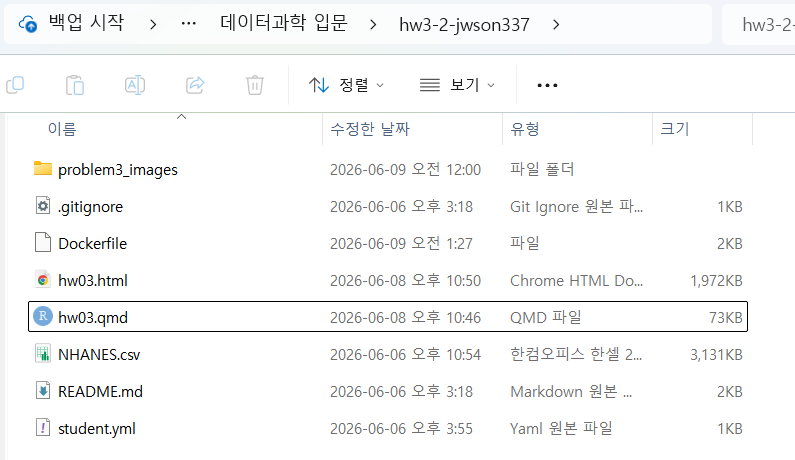
<figcaption aria-hidden="true">Dockerfile</figcaption>
</figure>

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

<figure>
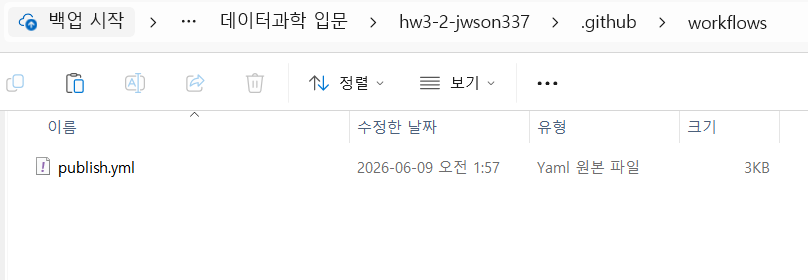
<figcaption aria-hidden="true">publish.yml</figcaption>
</figure>

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

<figure>
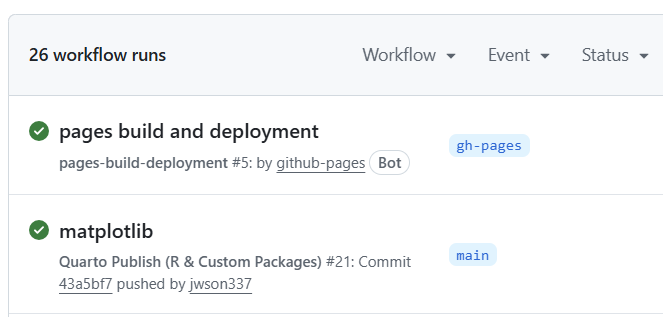
<figcaption aria-hidden="true">workflow 종료 확인</figcaption>
</figure>

<figure>
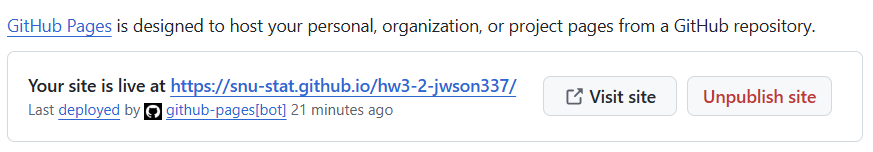
<figcaption aria-hidden="true">URL 확인</figcaption>
</figure>

<figure>
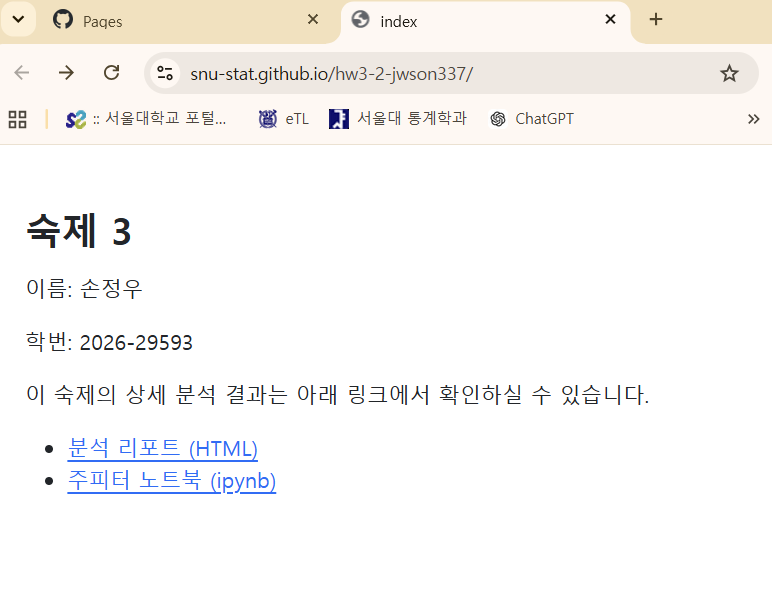
<figcaption aria-hidden="true">브라우저 작동 확인</figcaption>
</figure>

<figure>
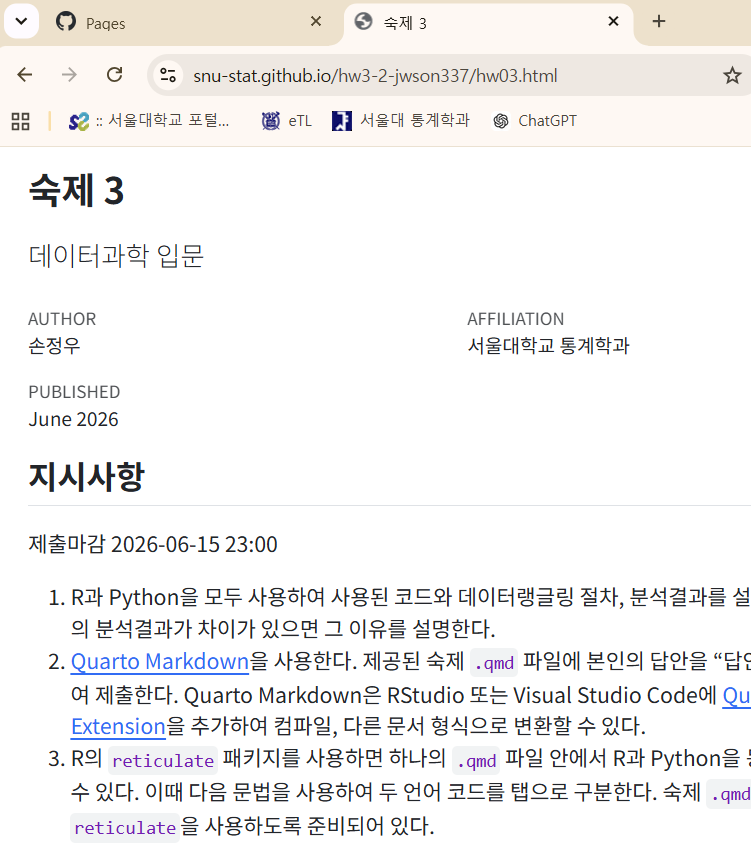
<figcaption aria-hidden="true">html 링크 작동 확인</figcaption>
</figure>

<figure>
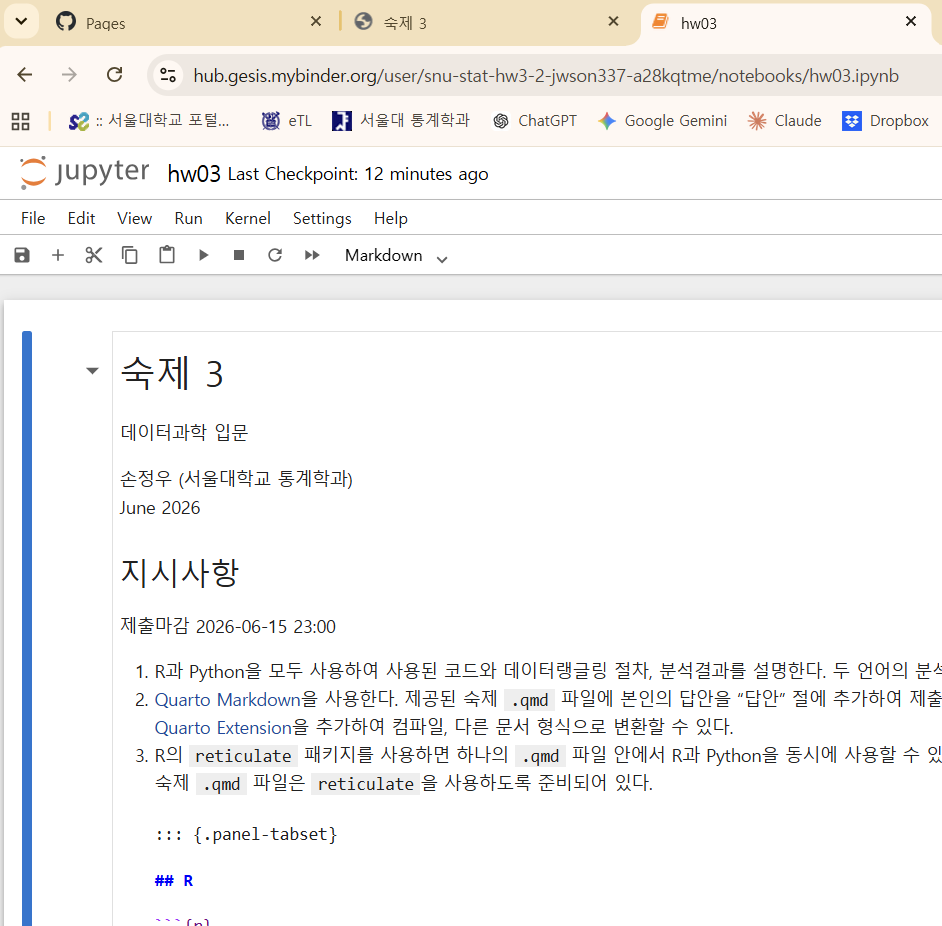
<figcaption aria-hidden="true">ipynb 링크 작동 확인</figcaption>
</figure>